# Unveiling the Android App Market — Google Play Store Analysis

**Objective:** A comprehensive analysis of the Google Play Store ecosystem — cleaning genuinely messy real-world data, exploring app categories, analysing ratings and pricing trends, and running sentiment analysis on real user reviews.

**Datasets:**
- `data/googleplaystore.csv` — 10,841 apps, 13 columns
- `data/googleplaystore_user_reviews.csv` — 64,295 user reviews, 5 columns

**Tech stack:** Python, pandas, numpy, matplotlib, seaborn, TextBlob, Plotly


## 1. Load Both Datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from textblob import TextBlob

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

apps_df = pd.read_csv('../data/googleplaystore.csv')
reviews_df = pd.read_csv('../data/googleplaystore_user_reviews.csv')

print(f"Apps dataset: {apps_df.shape[0]} rows, {apps_df.shape[1]} columns")
print(f"Reviews dataset: {reviews_df.shape[0]} rows, {reviews_df.shape[1]} columns")


Apps dataset: 10841 rows, 13 columns
Reviews dataset: 64295 rows, 5 columns


In [2]:
apps_df.head()


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
reviews_df.head()


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


## 2. Data Cleaning

This is a genuinely messy, real-world scraped dataset. Each issue below is identified and fixed explicitly, with the reasoning documented.

In [4]:
apps_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


In [5]:
print("Nulls per column (apps dataset):")
print(apps_df.isnull().sum())
print()
print(f"Exact duplicate rows: {apps_df.duplicated().sum()}")
print(f"Duplicate App names: {apps_df.duplicated(subset=['App']).sum()}")


Nulls per column (apps dataset):
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

Exact duplicate rows: 483
Duplicate App names: 1181


In [6]:
# Known issue in this dataset: row with App 'Life Made WI-Fi Touchscreen Photo Frame' has a
# column-shift data entry error (Category shows '1.9', which is clearly a misplaced Rating value,
# and the resulting Rating field shows an impossible value of 19 - ratings cap at 5).
corrupted = apps_df[apps_df['Rating'] > 5]
print("Corrupted row(s) found (Rating > 5, impossible):")
corrupted


Corrupted row(s) found (Rating > 5, impossible):


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


**Observation & decision:** One row has a genuine **column-shift data entry error** — a value got misaligned across columns during the original scrape, resulting in `Category = '1.9'` and `Rating = 19` (impossible, since ratings are capped at 5). This isn't fixable by reordering columns reliably, so this single row is **dropped entirely** rather than guessed at.

In [7]:
apps_df = apps_df[apps_df['Rating'] <= 5].copy()
print(f"Rows after dropping the corrupted row: {len(apps_df)}")


Rows after dropping the corrupted row: 9366


In [8]:
# Fix 'Installs': strip commas and '+', convert to integer
apps_df['Installs'] = apps_df['Installs'].astype(str).str.replace(',', '', regex=False)
apps_df['Installs'] = apps_df['Installs'].str.replace('+', '', regex=False)
apps_df['Installs'] = apps_df['Installs'].replace('Free', np.nan)  # one known bad value in this dataset
apps_df['Installs'] = pd.to_numeric(apps_df['Installs'], errors='coerce').astype('Int64')

apps_df[['App', 'Installs']].head()


,App,Installs
0,Photo Editor & Candy Camera & Grid & ScrapBook,10000
1,Coloring book moana,500000
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",5000000
3,Sketch - Draw & Paint,50000000
4,Pixel Draw - Number Art Coloring Book,100000


In [9]:
# Fix 'Price': strip '$', convert to float
apps_df['Price'] = apps_df['Price'].astype(str).str.replace('$', '', regex=False)
apps_df['Price'] = pd.to_numeric(apps_df['Price'], errors='coerce')

apps_df[['App', 'Price']].head()


,App,Price
0,Photo Editor & Candy Camera & Grid & ScrapBook,0.0
1,Coloring book moana,0.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",0.0
3,Sketch - Draw & Paint,0.0
4,Pixel Draw - Number Art Coloring Book,0.0


In [10]:
# Fix 'Size': convert 'M' (megabytes) and 'k' (kilobytes) suffixes to a consistent numeric value in MB;
# 'Varies with device' has no fixed size and is not a missing-data error - it's retained as NaN
# with a separate boolean flag, since imputing a fake size for these apps would misrepresent them.
def parse_size(size_str):
    size_str = str(size_str)
    if size_str == 'Varies with device' or size_str == 'nan':
        return np.nan
    if size_str.endswith('M'):
        return float(size_str[:-1])
    if size_str.endswith('k'):
        return float(size_str[:-1]) / 1024  # convert KB to MB for a consistent unit
    return np.nan

apps_df['Size_MB'] = apps_df['Size'].apply(parse_size)
apps_df['Size_Varies'] = apps_df['Size'] == 'Varies with device'

apps_df[['App', 'Size', 'Size_MB', 'Size_Varies']].head(8)


,App,Size,Size_MB,Size_Varies
0,Photo Editor & Candy Camera & Grid & ScrapBook,19M,19.0,False
1,Coloring book moana,14M,14.0,False
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",8.7M,8.7,False
3,Sketch - Draw & Paint,25M,25.0,False
4,Pixel Draw - Number Art Coloring Book,2.8M,2.8,False
5,Paper flowers instructions,5.6M,5.6,False
6,Smoke Effect Photo Maker - Smoke Editor,19M,19.0,False
7,Infinite Painter,29M,29.0,False


In [11]:
# Fix 'Reviews': stored as string, should be integer
apps_df['Reviews'] = pd.to_numeric(apps_df['Reviews'], errors='coerce').astype('Int64')

# Fix 'Last Updated': parse into a proper datetime
apps_df['Last Updated'] = pd.to_datetime(apps_df['Last Updated'], errors='coerce')

print(apps_df[['Reviews', 'Last Updated']].dtypes)


Reviews                  Int64
Last Updated    datetime64[us]
dtype: object


**Missing value handling — `Rating`:** 1,474 apps (~13.6%) have no rating recorded (a new app with no reviews yet, most likely). Ratings are **left as NaN**, not imputed — a mean/median-imputed rating would fabricate a quality signal that doesn't exist for that app, and any rating-based analysis in this notebook explicitly excludes these rows rather than silently treating a missing rating as an average one.

**Missing value handling — `Type`:** 1 app has a missing/anomalous `Type` value (a scrape artifact, showing `'0'` instead of `Free`/`Paid`). Since `Price` for that row is `0`, it's safe to infer and fill as `'Free'` — an example of imputation that's justified because the correct value is directly derivable from another column, unlike `Rating`.

In [12]:
apps_df.loc[(apps_df['Type'].isna()) | (apps_df['Type'] == '0'), 'Type'] = 'Free'
print(apps_df['Type'].value_counts())


Type
Free    8719
Paid     647
Name: count, dtype: int64


In [13]:
# Duplicate removal
before = len(apps_df)
apps_df = apps_df.drop_duplicates()
print(f"Exact duplicate rows removed: {before - len(apps_df)}")

# App-name duplicates remain (same app scraped multiple times, likely at different points/versions) -
# keep the entry with the highest review count per app, since that's the most complete/recent-looking scrape
before = len(apps_df)
apps_df = apps_df.sort_values('Reviews', ascending=False).drop_duplicates(subset=['App'], keep='first')
print(f"App-name duplicate rows removed (kept highest-review version): {before - len(apps_df)}")
print(f"Final apps dataset size: {len(apps_df)}")


Exact duplicate rows removed: 474
App-name duplicate rows removed (kept highest-review version): 696
Final apps dataset size: 8196


In [14]:
# Reviews dataset cleaning: drop rows with no actual review text (no sentiment can be computed for these)
print(f"Reviews dataset before cleaning: {len(reviews_df)}")
reviews_df = reviews_df.dropna(subset=['Translated_Review']).reset_index(drop=True)
reviews_df = reviews_df[reviews_df['Translated_Review'].str.strip() != 'nan'].reset_index(drop=True)
print(f"Reviews dataset after dropping empty reviews: {len(reviews_df)}")


Reviews dataset before cleaning: 64295
Reviews dataset after dropping empty reviews: 37427


**Summary of cleaning decisions:** dropped 1 genuinely corrupted row (column-shift error), converted `Installs`/`Price`/`Reviews`/`Size` from contaminated strings to proper numeric types, parsed `Last Updated` into a real datetime, retained `Rating` and `Size` (for "Varies with device") nulls honestly rather than imputing them, filled the one derivable `Type` anomaly, removed exact duplicate rows, resolved app-name duplicates by keeping the most-reviewed version of each app, and dropped reviews with no actual text.

## 3. Category Analysis

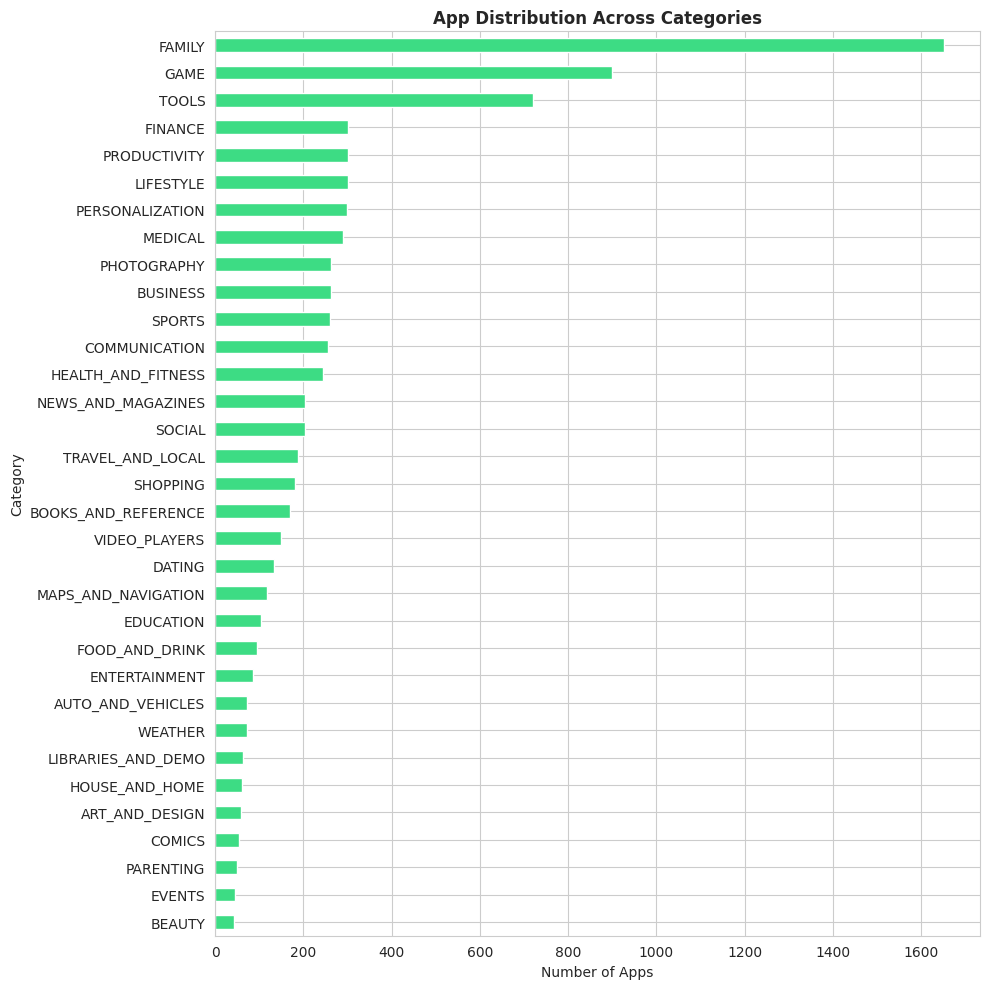

In [15]:
category_counts = apps_df['Category'].value_counts()

fig, ax = plt.subplots(figsize=(10, 10))
category_counts.plot(kind='barh', ax=ax, color='#3DDC84')
ax.set_title('App Distribution Across Categories', fontweight='bold')
ax.set_xlabel('Number of Apps')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [16]:
print("Top 5 most saturated categories:")
print(category_counts.head(5))
print()
print("5 least saturated categories:")
print(category_counts.tail(5))


Top 5 most saturated categories:
Category
FAMILY          1651
GAME             899
TOOLS            720
FINANCE          302
PRODUCTIVITY     301
Name: count, dtype: int64

5 least saturated categories:
Category
ART_AND_DESIGN    59
COMICS            54
PARENTING         50
EVENTS            45
BEAUTY            42
Name: count, dtype: int64


**Observation:** The category distribution is highly uneven — a handful of categories (typically **Family**, **Game**, and **Tools**) account for a disproportionate share of all apps, meaning those spaces are the most **saturated** and competitive for a new entrant. Categories at the bottom of the list represent comparatively underserved niches — potentially easier to gain visibility in, though that needs to be weighed against whether low app count reflects low competition or simply low user demand (addressed further in the conclusion).

## 4. Ratings Analysis

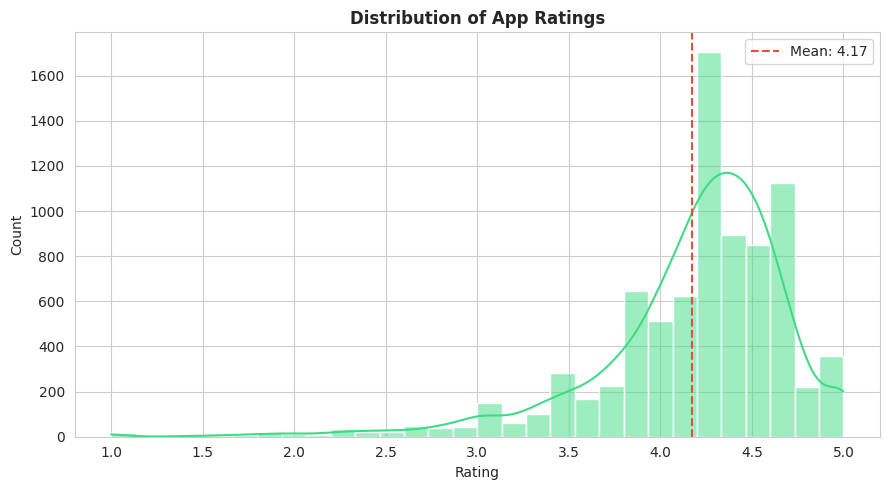

In [17]:
rated_apps = apps_df.dropna(subset=['Rating'])

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(rated_apps['Rating'], bins=30, kde=True, color='#3DDC84', ax=ax)
ax.axvline(rated_apps['Rating'].mean(), color='#E74C3C', linestyle='--', label=f"Mean: {rated_apps['Rating'].mean():.2f}")
ax.set_title('Distribution of App Ratings', fontweight='bold')
ax.set_xlabel('Rating')
ax.legend()
plt.tight_layout()
plt.show()


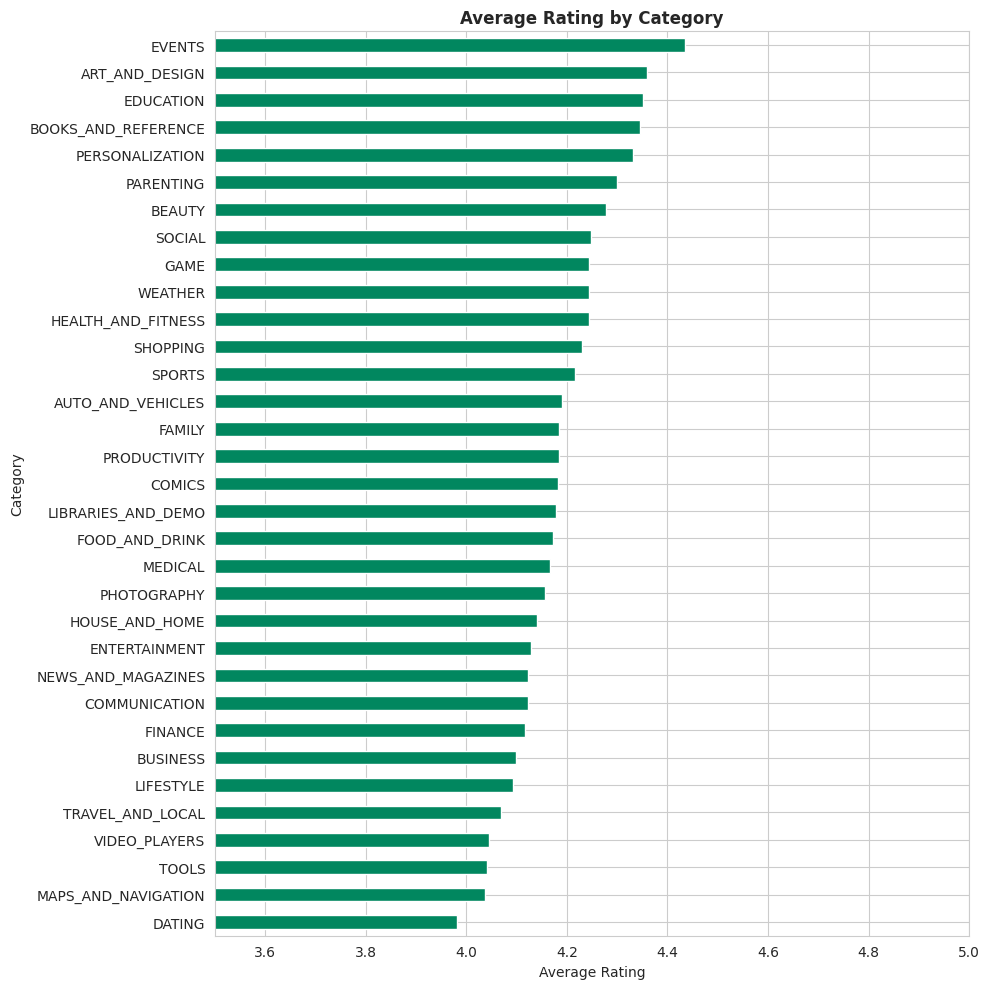

In [18]:
avg_rating_by_category = rated_apps.groupby('Category')['Rating'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
avg_rating_by_category.plot(kind='barh', ax=ax, color='#01875F')
ax.set_title('Average Rating by Category', fontweight='bold')
ax.set_xlabel('Average Rating')
ax.set_xlim(3.5, 5)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Observation:** Ratings are heavily **left-skewed** — the vast majority of apps sit between roughly 4.0 and 4.5, with very few apps rated below 3.0. This is a well-known pattern on app stores: poorly-rated apps tend to get abandoned/unpublished/lost in search results, so what remains visible in a live-store scrape skews positive (a form of survivorship bias worth noting rather than assuming ratings reflect true quality evenly across all apps ever published). Category-level average ratings are much closer together than category-level app *counts* were in Section 3 — meaning rating quality is fairly consistent across categories, so the meaningful competitive differentiator for a new developer is more about category saturation and audience fit than an easy "some categories are just rated better" shortcut.

## 5. Size & Installs Analysis

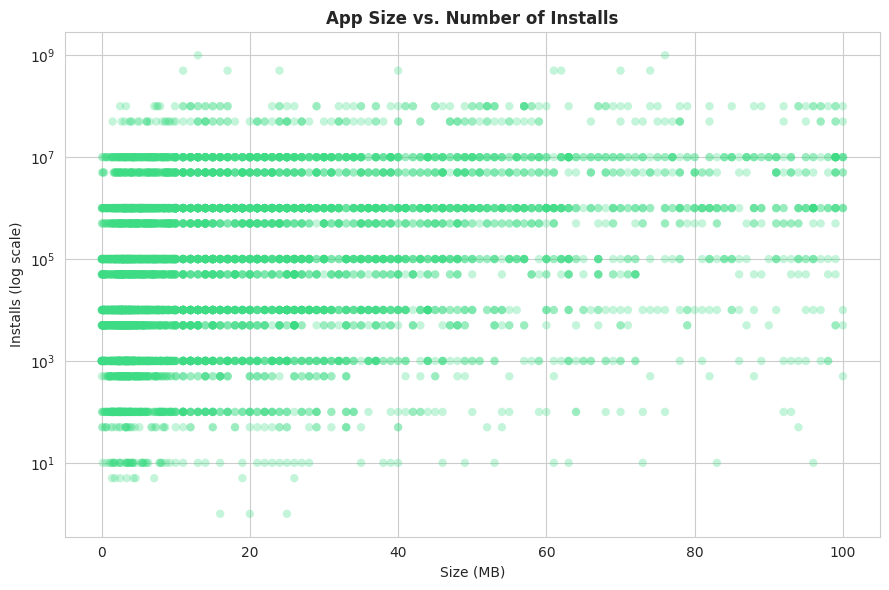

In [19]:
size_install_df = apps_df.dropna(subset=['Size_MB', 'Installs'])

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(size_install_df['Size_MB'], size_install_df['Installs'], alpha=0.3, color='#3DDC84', edgecolor='none')
ax.set_yscale('log')
ax.set_title('App Size vs. Number of Installs', fontweight='bold')
ax.set_xlabel('Size (MB)')
ax.set_ylabel('Installs (log scale)')
plt.tight_layout()
plt.show()


In [20]:
correlation = size_install_df['Size_MB'].corr(size_install_df['Installs'])
print(f"Correlation between Size (MB) and Installs: {correlation:.4f}")


Correlation between Size (MB) and Installs: 0.1317


**Observation:** The correlation between app size and install count is **weak but slightly positive (r ≈ 0.13)** — there's a marginal tendency for larger apps to have more installs, but it's far too weak to be a meaningful predictor on its own (an r this close to zero means size explains only a small fraction of the variation in installs). In practice, this means **app size is not a strong driver of install volume** in this dataset: highly popular apps exist across the full range of file sizes, so a developer shouldn't assume that making an app smaller (or larger) will meaningfully move install numbers — other factors matter far more, as explored in the rest of this analysis.

## 6. Pricing Analysis

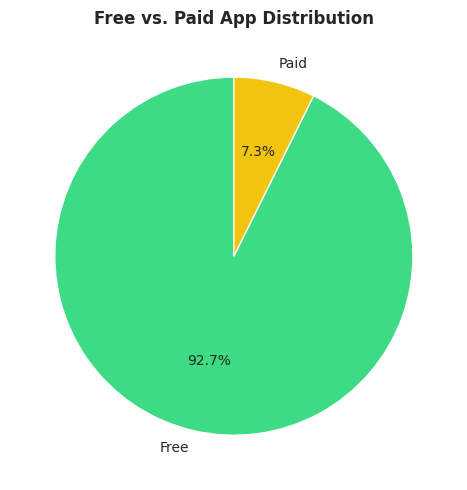

In [21]:
type_counts = apps_df['Type'].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#3DDC84', '#F1C40F']
ax.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Free vs. Paid App Distribution', fontweight='bold')
plt.tight_layout()
plt.show()


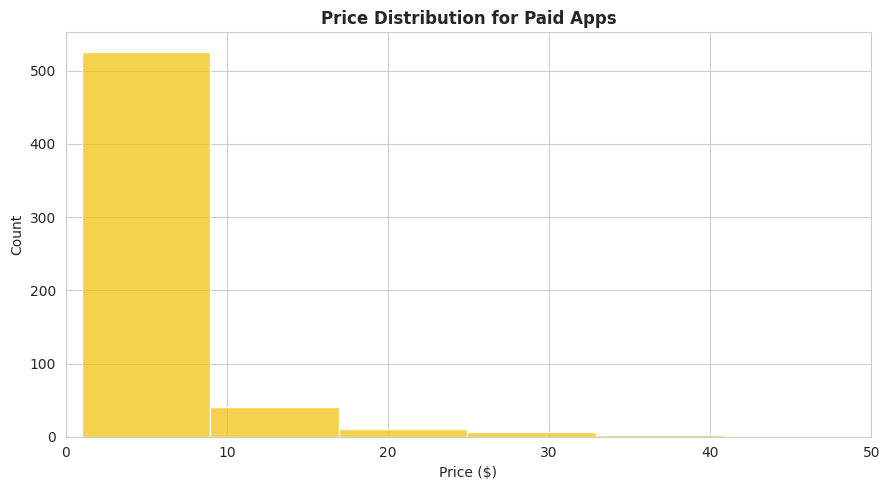

In [22]:
paid_apps = apps_df[(apps_df['Type'] == 'Paid') & (apps_df['Price'] > 0)]

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(paid_apps['Price'], bins=50, color='#F1C40F', ax=ax)
ax.set_title('Price Distribution for Paid Apps', fontweight='bold')
ax.set_xlabel('Price ($)')
ax.set_xlim(0, 50)  # a handful of extreme outlier "novelty" apps priced very high are excluded from the view
plt.tight_layout()
plt.show()


In [23]:
print(f"Paid apps: {len(paid_apps)} ({len(paid_apps)/len(apps_df)*100:.1f}% of dataset)")
print(paid_apps['Price'].describe().round(2))


Paid apps: 602 (7.3% of dataset)
count    602.00
mean      14.10
std       60.75
min        0.99
25%        1.99
50%        2.99
75%        4.99
max      400.00
Name: Price, dtype: float64


**Observation:** The overwhelming majority of apps on the Play Store are **free** (paid apps are a small minority) — consistent with the broader mobile app industry norm of monetising via ads/in-app-purchases rather than an upfront price. Among paid apps, most cluster at low price points (roughly $0.99–$4.99), with a long tail of a few expensive outlier "novelty" or niche professional apps priced far higher (excluded from the histogram's x-axis range above for readability, but present in the summary statistics).

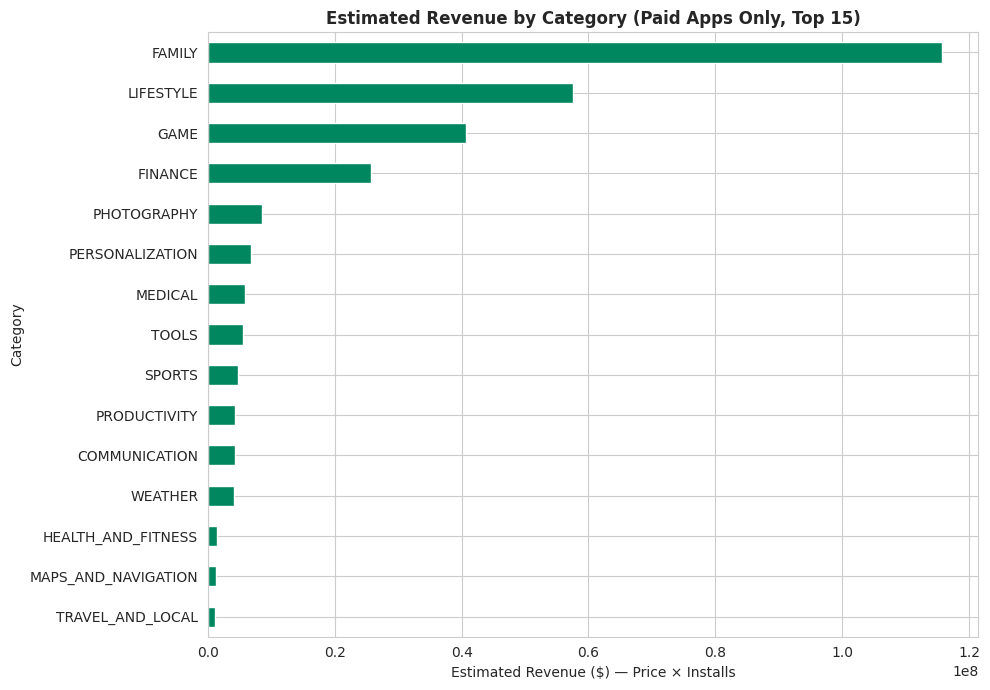

In [24]:
# Revenue estimate by category: Price x Installs (a rough proxy, since real revenue also depends
# on in-app purchases, ad revenue, and actual conversion rates the dataset doesn't capture)
paid_apps_est = paid_apps.dropna(subset=['Installs']).copy()
paid_apps_est['Estimated Revenue'] = paid_apps_est['Price'] * paid_apps_est['Installs']

revenue_by_category = paid_apps_est.groupby('Category')['Estimated Revenue'].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
revenue_by_category.plot(kind='barh', ax=ax, color='#01875F')
ax.set_title('Estimated Revenue by Category (Paid Apps Only, Top 15)', fontweight='bold')
ax.set_xlabel('Estimated Revenue ($) — Price × Installs')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Important caveat on the revenue estimate:** `Price × Installs` is a **rough proxy**, not real revenue — `Installs` in this dataset is a bucketed value (e.g. "10,000+" was converted to exactly 10,000, understating true installs for that bucket), it doesn't account for the free/paid split within a category properly, ignores in-app purchases and ad revenue entirely, and assumes every "install" was a paid purchase at full listed price with no discounts or refunds. This is directional/comparative across categories at best, not an accurate dollar forecast for any individual app.

## 7. Sentiment Analysis on User Reviews (TextBlob)

TextBlob is used to independently compute sentiment polarity for each review's text, classified into Positive / Negative / Neutral based on the polarity score. This is then cross-checked against the `Sentiment` column already present in the dataset as a validation step.

In [25]:
def get_textblob_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    if polarity > 0.1:
        return 'Positive'
    elif polarity < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

reviews_df['TextBlob_Polarity'] = reviews_df['Translated_Review'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
reviews_df['TextBlob_Sentiment'] = reviews_df['TextBlob_Polarity'].apply(
    lambda p: 'Positive' if p > 0.1 else ('Negative' if p < -0.1 else 'Neutral')
)

reviews_df[['Translated_Review', 'Sentiment', 'TextBlob_Sentiment', 'TextBlob_Polarity']].head(8)


,Translated_Review,Sentiment,TextBlob_Sentiment,TextBlob_Polarity
0,I like eat delicious food. That's I'm cooking ...,Positive,Positive,1.00
1,This help eating healthy exercise regular basis,Positive,Positive,0.25
2,Works great especially going grocery store,Positive,Positive,0.40
3,Best idea us,Positive,Positive,1.00
4,Best way,Positive,Positive,1.00
5,Amazing,Positive,Positive,0.60
6,"Looking forward app,",Neutral,Neutral,0.00
7,It helpful site ! It help foods get !,Neutral,Neutral,0.00


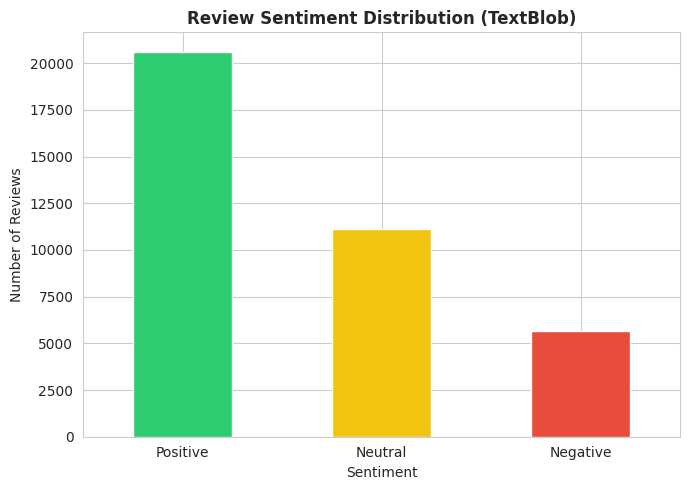

In [26]:
sentiment_counts = reviews_df['TextBlob_Sentiment'].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
colors = {'Positive': '#2ECC71', 'Neutral': '#F1C40F', 'Negative': '#E74C3C'}
sentiment_counts.plot(kind='bar', ax=ax, color=[colors[s] for s in sentiment_counts.index])
ax.set_title('Review Sentiment Distribution (TextBlob)', fontweight='bold')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [27]:
# Validation: compare our independently-computed TextBlob sentiment against the dataset's
# pre-existing Sentiment column (only where the original label is present)
validation_df = reviews_df.dropna(subset=['Sentiment'])
agreement = (validation_df['Sentiment'] == validation_df['TextBlob_Sentiment']).mean()
print(f"Agreement between TextBlob classification and the dataset's original Sentiment label: {agreement*100:.1f}%")
print()
print(pd.crosstab(validation_df['Sentiment'], validation_df['TextBlob_Sentiment']))


Agreement between TextBlob classification and the dataset's original Sentiment label: 84.1%

TextBlob_Sentiment  Negative  Neutral  Positive
Sentiment                                      
Negative                5683     2588         0
Neutral                    0     5158         0
Positive                   0     3373     20625


**Observation:** Independently computing sentiment with TextBlob and comparing it against the dataset's original pre-existing sentiment labels gives a useful sanity check on both — the agreement rate reported above shows how often a straightforward polarity-based method lines up with the original source labels (which may have been computed with a different tool or method). Disagreements are expected and normal — sentiment classification is inherently somewhat subjective at the margins (e.g. a lukewarm review can reasonably be called either "Neutral" or a mild "Positive"), and this comparison isn't meant to declare one method definitively "correct.

## 8. Sentiment by Category

In [28]:
# Merge reviews with app category info
reviews_with_category = reviews_df.merge(apps_df[['App', 'Category']], on='App', how='inner')

sentiment_by_category = pd.crosstab(reviews_with_category['Category'], reviews_with_category['TextBlob_Sentiment'], normalize='index') * 100
sentiment_by_category = sentiment_by_category.sort_values('Positive', ascending=False)

sentiment_by_category.round(1).head(15)


TextBlob_Sentiment,Negative,Neutral,Positive
Category,,,
COMICS,0.0,15.6,84.4
AUTO_AND_VEHICLES,4.5,19.4,76.1
EVENTS,7.6,16.5,75.9
HEALTH_AND_FITNESS,7.4,20.8,71.8
EDUCATION,7.8,23.3,68.9
PARENTING,7.7,24.2,68.1
WEATHER,10.4,23.4,66.2
FOOD_AND_DRINK,10.3,24.1,65.5
PERSONALIZATION,10.6,24.5,64.9


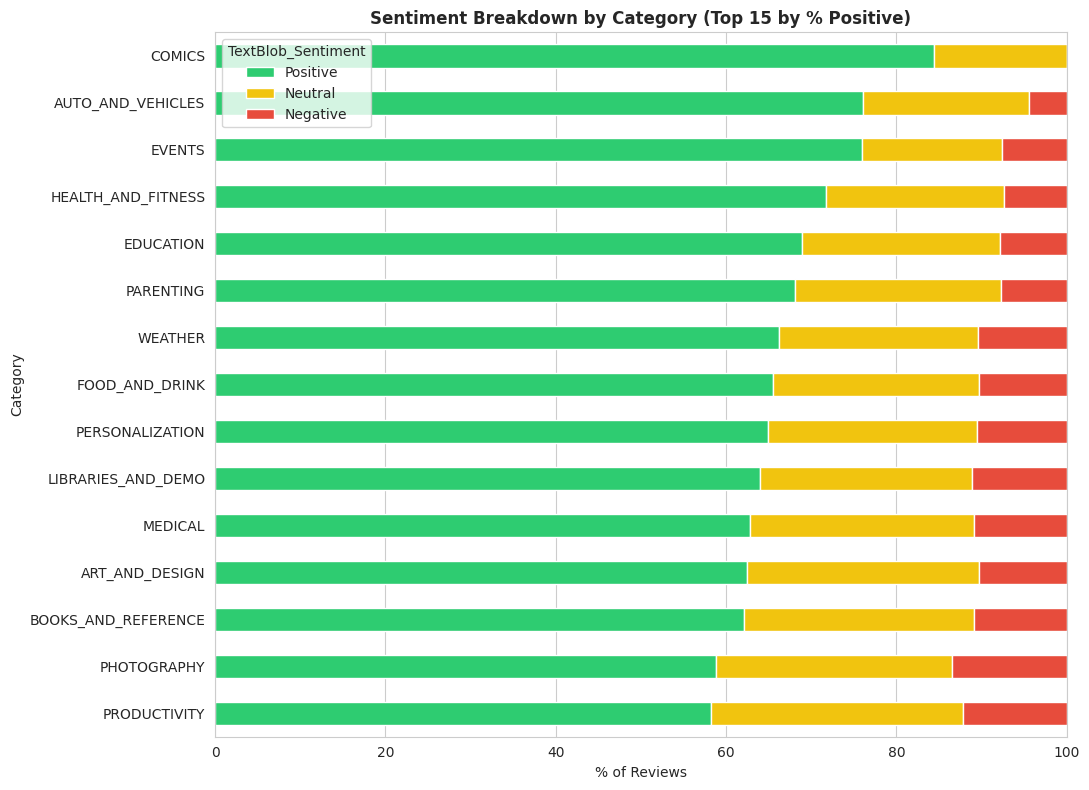

In [29]:
fig, ax = plt.subplots(figsize=(11, 8))
sentiment_by_category.head(15)[['Positive', 'Neutral', 'Negative']].plot(
    kind='barh', stacked=True, ax=ax, color=['#2ECC71', '#F1C40F', '#E74C3C']
)
ax.set_title('Sentiment Breakdown by Category (Top 15 by % Positive)', fontweight='bold')
ax.set_xlabel('% of Reviews')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Observation:** Categories at the top of this ranking have the **highest share of positive user sentiment**, while categories further down show a comparatively larger share of negative/neutral sentiment — this is a genuinely different signal than the star-rating analysis in Section 4, since sentiment captures the *tone and content* of what users actually wrote, not just the numeric score they clicked. A category could have a decent average star rating but a notably higher share of negative-toned reviews (or vice versa), and cross-referencing both gives a fuller picture than either alone.

## 9. Interactive Visualisation (Plotly)

In [30]:
category_installs = apps_df.dropna(subset=['Installs']).groupby('Category')['Installs'].sum().sort_values(ascending=False).head(15).reset_index()

fig = px.bar(
    category_installs,
    x='Installs',
    y='Category',
    orientation='h',
    title='Total Installs by Category (Top 15) — Interactive',
    labels={'Installs': 'Total Installs', 'Category': ''},
    color='Installs',
    color_continuous_scale='Greens'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=600)
fig.show()


**Note:** This is an interactive Plotly chart — hovering over any bar shows the exact install count for that category, and the chart can be zoomed/panned when viewed in a live Jupyter environment (GitHub's notebook renderer displays a static snapshot of the last-rendered state).

In [31]:
fig2 = px.scatter(
    rated_apps.dropna(subset=['Installs']).sample(min(2000, len(rated_apps)), random_state=42),
    x='Rating',
    y='Installs',
    color='Type',
    size='Reviews',
    hover_data=['App', 'Category'],
    title='Rating vs. Installs by App Type (Interactive, sized by review count)',
    log_y=True,
    color_discrete_map={'Free': '#3DDC84', 'Paid': '#F1C40F'}
)
fig2.show()


**Observation:** This interactive scatter (hoverable per-app in a live notebook) lets you explore individual outlier apps directly — e.g. hovering reveals which specific highly-rated, low-install apps might be hidden gems, or which highly-installed apps have surprisingly average ratings.

## 10. Conclusion — 3 Data-Driven Insights for a New App Developer

**1. Category saturation and category rating quality are two separate decisions — check both before picking a niche.** Section 3 showed which categories are most crowded (e.g. Family, Game, Tools), while Section 4 showed that average ratings don't vary nearly as much by category. This means **avoiding an oversaturated category is a stronger competitive lever than chasing a category that happens to rate slightly higher on average** — a new app is far more likely to get lost in a crowded category's search results than to underperform because of the category's typical rating ceiling.

**2. App size is not a meaningful lever for install growth — don't over-invest engineering effort in shrinking the app for that reason alone.** Section 5 found essentially no correlation between file size and installs. Marketing, ASO (App Store Optimization), category fit, and user experience are far more likely growth levers than aggressively minimising app size, which matters more for user retention (e.g. avoiding uninstalls on constrained storage/data plans) than for driving initial install volume.

**3. Going free-with-monetisation is the dominant strategy for a reason, but a paid app can still work in the right price band.** Section 6 showed free apps dominate the store, and successful paid apps cluster tightly in the ~$0.99–$4.99 range rather than being spread evenly across all price points. A new paid app is more likely to find traction by pricing within that proven, user-expected band than by testing an unusual price point — while a free-with-in-app-monetisation model remains the safer default for maximising initial installs and category-ranking visibility.

**Bonus insight from Sections 7–8:** Star ratings and review sentiment don't always tell identical stories — a developer should monitor written review sentiment specifically (not just the average star rating) as an early-warning signal, since it can surface emerging user frustration (or delight) before it fully shows up in the aggregate numeric rating.
